# Task 1 - Build a Baseline and Evaluate It Honestly

**Course 2: Computer Vision and Pretrained Models · Day 1, Lab (3 hours)**

### What you are doing

You will build a CNN from scratch on the weather dataset, train it **twice** — once without augmentation and once with — and then evaluate the better model properly, using a confusion matrix and per-class precision and recall.

### Why the two runs matter

Anyone can train a model and report a number. The skill worth having is knowing whether a change actually helped, which requires a controlled comparison: change *one* thing, hold everything else fixed, measure the difference.

### The deliverable

At the end you must record your **test accuracy** and **macro F1**. You will use both tomorrow as the baseline that transfer learning has to beat.

### How this notebook works

Cells marked **`### TODO`** are yours to complete. Each is followed by a **check cell** that verifies your work — run it and fix anything it complains about before moving on.

### Time plan

| Part | Minutes | What |
|---|---|---|
| 0 | 10 | Setup and data loading |
| 1 | 25 | Stratified split *(TODO)* |
| 2 | 30 | Build the CNN *(TODO)* |
| 3 | 20 | Run A — no augmentation |
| 4 | 20 | Run B — with augmentation |
| 5 | 15 | Compare the two runs |
| 6 | 40 | Confusion matrix and per-class metrics *(TODO)* |
| 7 | 25 | Written analysis |

---

## Part 0 — Setup

Before you start: **⋮ → Accelerator → GPU**, **⋮ → Internet → On**, **+ Add Input →** `jehanbhathena/weather-dataset`.

In [3]:
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("*** No GPU. Enable it before continuing or this lab will take hours. ***")

Device: cuda


In [4]:
# Dataset discovery (same helper as the session notebook)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_dataset_root(start=Path("/kaggle/input"), min_classes=5):
    def is_class_folder(d):
        if not d.is_dir():
            return False
        n = 0
        for p in d.iterdir():
            if p.suffix.lower() in IMG_EXT:
                n += 1
                if n >= 20:
                    return True
        return False
    for d in [start] + sorted(p for p in start.rglob("*") if p.is_dir()):
        subs = [s for s in d.iterdir() if s.is_dir()]
        if len(subs) >= min_classes and all(is_class_folder(s) for s in subs):
            return d
    raise FileNotFoundError("Dataset not found. Did you attach weather-dataset?")

DATA_ROOT = find_dataset_root()
full = ImageFolder(DATA_ROOT)
CLASSES = full.classes
NUM_CLASSES = len(CLASSES)
targets = np.array(full.targets)

print("Root   :", DATA_ROOT)
print("Images :", len(full))
print("Classes:", NUM_CLASSES, CLASSES)

Root   : /kaggle/input/datasets/jehanbhathena/weather-dataset/dataset
Images : 6862
Classes: 11 ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


---

## Part 1 — Split the data *(TODO)*

Produce three stratified splits: **70% train, 15% validation, 15% test**.

`train_test_split` only splits in two, so you will need it twice: first peel off 30%, then halve that into val and test. Pass `stratify=` both times — and on the second call, remember to stratify against the labels *of the subset you are splitting*, not the whole dataset.

Use `random_state=SEED` so your results are reproducible.

In [5]:
### TODO 1 -----------------------------------------------------------------
# Create three arrays of indices: train_idx, val_idx, test_idx
# Requirements: 70/15/15, stratified by `targets`, random_state=SEED

idx = np.arange(len(full))

train_idx, tmp_idx =  train_test_split(
    idx,
    test_size=0.30,
    stratify=targets,
    random_state=SEED
)  # TODO: split off 30% into tmp_idx
val_idx, test_idx = train_test_split(
    tmp_idx,
    test_size=0.50,
    stratify=targets[tmp_idx],
    random_state=SEED
)    # TODO: split tmp_idx in half

# --------------------------------------------------------------------------

In [6]:
# --- CHECK 1 ---
assert isinstance(train_idx, np.ndarray), "train_idx must be a numpy array"
n = len(full)
assert abs(len(train_idx) / n - 0.70) < 0.02, f"train should be ~70%, got {len(train_idx)/n:.1%}"
assert abs(len(val_idx) / n - 0.15) < 0.02, f"val should be ~15%, got {len(val_idx)/n:.1%}"
assert abs(len(test_idx) / n - 0.15) < 0.02, f"test should be ~15%, got {len(test_idx)/n:.1%}"
assert len(set(train_idx) & set(val_idx)) == 0, "train and val overlap!"
assert len(set(train_idx) & set(test_idx)) == 0, "train and test overlap!"
assert len(set(val_idx) & set(test_idx)) == 0, "val and test overlap!"

for c in range(NUM_CLASSES):
    overall = (targets == c).mean()
    for nm, ix in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
        got = (targets[ix] == c).mean()
        assert abs(got - overall) < 0.02, \
            f"{CLASSES[c]} is {got:.1%} of {nm} but {overall:.1%} overall - not stratified"

print(f"PASSED. train {len(train_idx)}  val {len(val_idx)}  test {len(test_idx)}")
print("All 11 classes keep their proportions in every split.")

PASSED. train 4803  val 1029  test 1030
All 11 classes keep their proportions in every split.


### Class balance — look at this before you go further

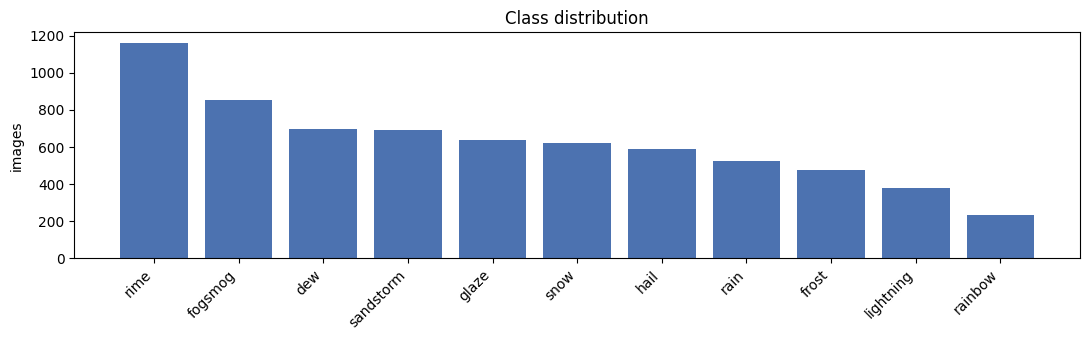

Largest : rime (1160)
Smallest: rainbow (232)
Ratio   : 5.0x

A model that never predicts 'rainbow' loses only 3.4% accuracy. Keep that in mind in Part 6.


In [7]:
counts = np.bincount(targets, minlength=NUM_CLASSES)
order = np.argsort(-counts)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar([CLASSES[i] for i in order], counts[order], color="#4C72B0")
ax.set_ylabel("images")
ax.set_title("Class distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Largest : {CLASSES[order[0]]} ({counts[order[0]]})")
print(f"Smallest: {CLASSES[order[-1]]} ({counts[order[-1]]})")
print(f"Ratio   : {counts[order[0]] / counts[order[-1]]:.1f}x")
print(f"\nA model that never predicts '{CLASSES[order[-1]]}' loses only "
      f"{100*counts[order[-1]]/counts.sum():.1f}% accuracy. Keep that in mind in Part 6.")

---

## Part 2 — Transforms and the model *(TODO)*

### 2a. Two transform pipelines

You need **`eval_tf`** (deterministic — used for validation and test) and **`train_tf_aug`** (augmented — used only for Run B).

Recall the ordering rule: geometry and colour operate on PIL images, so they come *before* `ToTensor()`. `Normalize` comes *after*.

For the augmented pipeline, choose transforms that are defensible for weather photographs. Section 4 of the session notebook argued that vertical flips and aggressive colour jitter would actively hurt this dataset — do not use them.

In [8]:
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

### TODO 2a ----------------------------------------------------------------
# eval_tf      : Resize -> ToTensor -> Normalize    (no randomness at all)
# train_tf_aug : add 2-4 sensible random augmentations before ToTensor

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])       # TODO

train_tf_aug = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])  # TODO

# --------------------------------------------------------------------------

# Run A uses NO augmentation, so its training transform is just eval_tf
train_tf_plain = eval_tf

In [9]:
# --- CHECK 2a ---
_probe = Image.open(full.samples[0][0]).convert("RGB")

out = eval_tf(_probe)
assert out.shape == (3, IMG_SIZE, IMG_SIZE), f"eval_tf gave {tuple(out.shape)}, expected (3,{IMG_SIZE},{IMG_SIZE})"
assert out.min() < -0.5, "eval_tf output does not look normalized - did you include Normalize?"

a, b = eval_tf(_probe), eval_tf(_probe)
assert torch.allclose(a, b), "eval_tf is random! It must be deterministic - remove random transforms."

a, b = train_tf_aug(_probe), train_tf_aug(_probe)
assert a.shape == (3, IMG_SIZE, IMG_SIZE), f"train_tf_aug gave {tuple(a.shape)}"
assert not torch.allclose(a, b), "train_tf_aug is NOT random - it needs random augmentations."

names = [type(t).__name__ for t in train_tf_aug.transforms]
assert "RandomVerticalFlip" not in names, "Vertical flip is wrong for weather photos - skies are not upside down."
assert "Grayscale" not in names, "Grayscale destroys the colour cues that define rainbow and sandstorm."

print("PASSED.")
print("eval_tf      :", [type(t).__name__ for t in eval_tf.transforms])
print("train_tf_aug :", names)

PASSED.
eval_tf      : ['Resize', 'ToTensor', 'Normalize']
train_tf_aug : ['RandomResizedCrop', 'RandomHorizontalFlip', 'RandomRotation', 'ToTensor', 'Normalize']


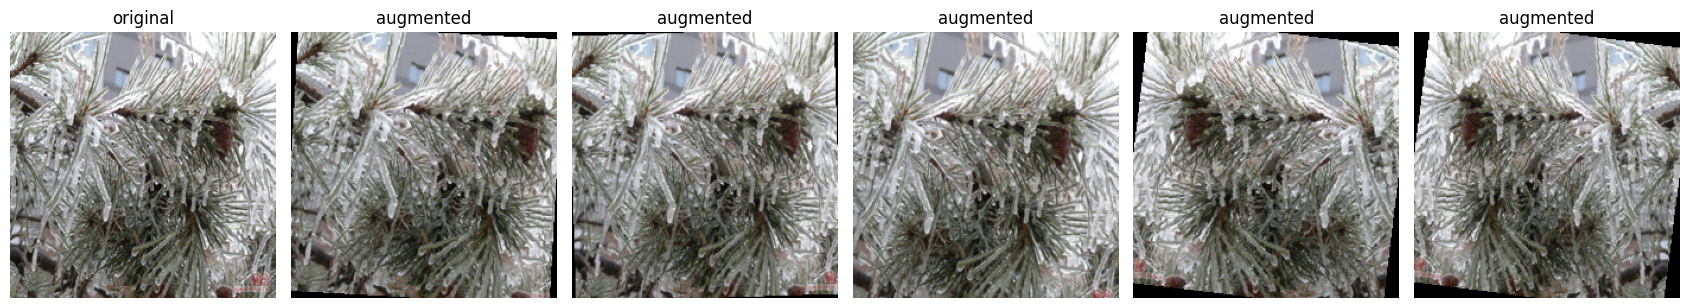

In [10]:
# Look at your augmentations. If they are unrecognisable, they are too strong.
def denorm(t):
    m, s = torch.tensor(MEAN).view(3,1,1), torch.tensor(STD).view(3,1,1)
    return (t * s + m).clamp(0, 1).permute(1, 2, 0)

src = Image.open(full.samples[len(full)//3][0]).convert("RGB")
fig, axes = plt.subplots(1, 6, figsize=(17, 3.2))
axes[0].imshow(src.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title("original"); axes[0].axis("off")
for ax in axes[1:]:
    ax.imshow(denorm(train_tf_aug(src))); ax.set_title("augmented"); ax.axis("off")
plt.tight_layout(); plt.show()

### 2b. Dataset wrapper and loaders

This is given to you — it lets each split carry its own transform.

In [11]:
class SplitDataset(Dataset):
    def __init__(self, base, indices, transform):
        self.base, self.indices, self.transform = base, list(indices), transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        return self.transform(Image.open(path).convert("RGB")), label


BATCH_SIZE = 32
NUM_WORKERS = 2

def make_loaders(train_transform):
    common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
    return (
        DataLoader(SplitDataset(full, train_idx, train_transform), shuffle=True,  **common),
        DataLoader(SplitDataset(full, val_idx,   eval_tf),         shuffle=False, **common),
        DataLoader(SplitDataset(full, test_idx,  eval_tf),         shuffle=False, **common),
    )

print("Loader factory ready.")

Loader factory ready.


### 2c. Build the CNN *(TODO)*

Complete `WeatherCNN`. The structure is four blocks, each of which:

1. `Conv2d` with `kernel_size=3, padding=1` — keeps the spatial size unchanged
2. `BatchNorm2d`
3. `ReLU`
4. `MaxPool2d(2)` — halves the spatial size

Channel progression: `3 → 32 → 64 → 128 → 256`.

After four halvings, 224 becomes 14. `AdaptiveAvgPool2d(1)` then collapses 14×14 to 1×1, so the classifier receives 256 features.

**Before you write any code, fill this in on paper:**

| After | Channels | Height | Width |
|---|---|---|---|
| input | 3 | 224 | 224 |
| block 1 | 32 | ? | ? |
| block 2 | ? | ? | ? |
| block 3 | ? | ? | ? |
| block 4 | ? | ? | ? |
| adaptive pool | ? | 1 | 1 |

In [12]:
### TODO 2c ----------------------------------------------------------------
class WeatherCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_ch, out_ch):
            # TODO: return an nn.Sequential of
            return nn.Sequential(
            #       Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
                nn.Conv2d(in_ch,out_ch,kernel_size=3,padding=1),
            #       BatchNorm2d(out_ch)
                nn.BatchNorm2d(out_ch),
            #       ReLU(inplace=True)
                nn.ReLU(inplace=True),
            #       MaxPool2d(2)
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(block(3,32),block(32,64),block(64,128),block(128,256))      # TODO: nn.Sequential of four blocks, 3->32->64->128->256
        self.pool =   nn.AdaptiveAvgPool2d(1)        # TODO: nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256,num_classes)                  # TODO: nn.Linear from 256 to num_classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x
# --------------------------------------------------------------------------

In [13]:
# --- CHECK 2c ---
_m = WeatherCNN(NUM_CLASSES)
_x = torch.randn(4, 3, 224, 224)
_out = _m(_x)

assert _out is not None, "forward() returned None - did you forget to return?"
assert _out.shape == (4, NUM_CLASSES), f"output {tuple(_out.shape)}, expected (4, {NUM_CLASSES})"

_h = _x
expected = [(32,112), (64,56), (128,28), (256,14)]
for i, blk in enumerate(_m.features):
    _h = blk(_h)
    ec, es = expected[i]
    assert _h.shape[1:] == (ec, es, es), \
        f"after block {i+1} got {tuple(_h.shape[1:])}, expected ({ec}, {es}, {es})"
    print(f"  block {i+1}: {tuple(_h.shape)}")

_p = sum(p.numel() for p in _m.parameters())
assert 200_000 < _p < 800_000, f"{_p:,} parameters looks wrong - check your channel sizes"
print(f"\nPASSED. {_p:,} parameters.")

  block 1: (4, 32, 112, 112)
  block 2: (4, 64, 56, 56)
  block 3: (4, 128, 28, 28)
  block 4: (4, 256, 14, 14)

PASSED. 392,203 parameters.


---

## Part 3 — The training loop

Given to you. Read it — you need to understand it for tomorrow.

In [14]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n


def fit(model, train_loader, val_loader, epochs, lr=1e-3, tag=""):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    t_start = time.time()

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        for k, v in zip(hist, [tr_loss, va_loss, tr_acc, va_acc]):
            hist[k].append(v)
        star = ""
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            star = "  <- best"
        print(f"[{tag}] epoch {ep:2d}/{epochs}  "
              f"train {tr_loss:.3f}/{tr_acc:.3f}   val {va_loss:.3f}/{va_acc:.3f}  "
              f"({time.time()-t0:.0f}s){star}")

    if best_state:
        model.load_state_dict(best_state)
    hist["total_time"] = time.time() - t_start
    hist["best_val_acc"] = best_acc
    print(f"[{tag}] done in {hist['total_time']/60:.1f} min, best val acc {best_acc:.1%}")
    return model, hist

---

## Part 4 — Run A: no augmentation

**~6 minutes.** Everything is identical between Run A and Run B *except* the training transform. That is what makes this a controlled experiment.

In [15]:
EPOCHS = 15

torch.manual_seed(SEED)
train_loader_A, val_loader, test_loader = make_loaders(train_tf_plain)
model_A = WeatherCNN(NUM_CLASSES)
model_A, hist_A = fit(model_A, train_loader_A, val_loader, epochs=EPOCHS, tag="A no-aug")

[A no-aug] epoch  1/15  train 1.372/0.533   val 1.164/0.604  (40s)  <- best
[A no-aug] epoch  2/15  train 1.173/0.598   val 1.215/0.581  (25s)
[A no-aug] epoch  3/15  train 1.100/0.626   val 1.069/0.627  (26s)  <- best
[A no-aug] epoch  4/15  train 1.049/0.642   val 1.240/0.594  (25s)
[A no-aug] epoch  5/15  train 0.995/0.654   val 0.954/0.679  (26s)  <- best
[A no-aug] epoch  6/15  train 0.948/0.678   val 1.017/0.670  (25s)
[A no-aug] epoch  7/15  train 0.915/0.688   val 1.180/0.603  (25s)
[A no-aug] epoch  8/15  train 0.868/0.703   val 0.918/0.704  (26s)  <- best
[A no-aug] epoch  9/15  train 0.860/0.705   val 1.019/0.664  (26s)
[A no-aug] epoch 10/15  train 0.849/0.710   val 0.869/0.722  (26s)  <- best
[A no-aug] epoch 11/15  train 0.811/0.729   val 0.844/0.732  (26s)  <- best
[A no-aug] epoch 12/15  train 0.800/0.728   val 0.774/0.749  (25s)  <- best
[A no-aug] epoch 13/15  train 0.746/0.748   val 0.816/0.738  (26s)
[A no-aug] epoch 14/15  train 0.739/0.748   val 0.938/0.701  (25s)

---

## Part 5 — Run B: with augmentation

**~6 minutes.** Same seed, same architecture, same epochs, same learning rate. Only the training transform differs.

In [16]:
torch.manual_seed(SEED)
train_loader_B, _, _ = make_loaders(train_tf_aug)
model_B = WeatherCNN(NUM_CLASSES)
model_B, hist_B = fit(model_B, train_loader_B, val_loader, epochs=EPOCHS, tag="B aug  ")

[B aug  ] epoch  1/15  train 1.383/0.531   val 1.195/0.598  (27s)  <- best
[B aug  ] epoch  2/15  train 1.187/0.592   val 1.264/0.579  (27s)
[B aug  ] epoch  3/15  train 1.121/0.620   val 1.063/0.641  (28s)  <- best
[B aug  ] epoch  4/15  train 1.074/0.633   val 1.081/0.634  (28s)
[B aug  ] epoch  5/15  train 1.010/0.643   val 0.982/0.668  (28s)  <- best
[B aug  ] epoch  6/15  train 0.967/0.668   val 1.143/0.634  (28s)
[B aug  ] epoch  7/15  train 0.946/0.684   val 1.060/0.642  (28s)
[B aug  ] epoch  8/15  train 0.898/0.698   val 0.921/0.704  (27s)  <- best
[B aug  ] epoch  9/15  train 0.894/0.696   val 0.984/0.685  (27s)
[B aug  ] epoch 10/15  train 0.882/0.697   val 0.939/0.698  (27s)
[B aug  ] epoch 11/15  train 0.846/0.716   val 0.843/0.727  (28s)  <- best
[B aug  ] epoch 12/15  train 0.836/0.717   val 0.887/0.703  (28s)
[B aug  ] epoch 13/15  train 0.787/0.730   val 0.817/0.739  (27s)  <- best
[B aug  ] epoch 14/15  train 0.784/0.735   val 1.026/0.673  (27s)
[B aug  ] epoch 15/15 

---

## Part 6 — Compare the two runs

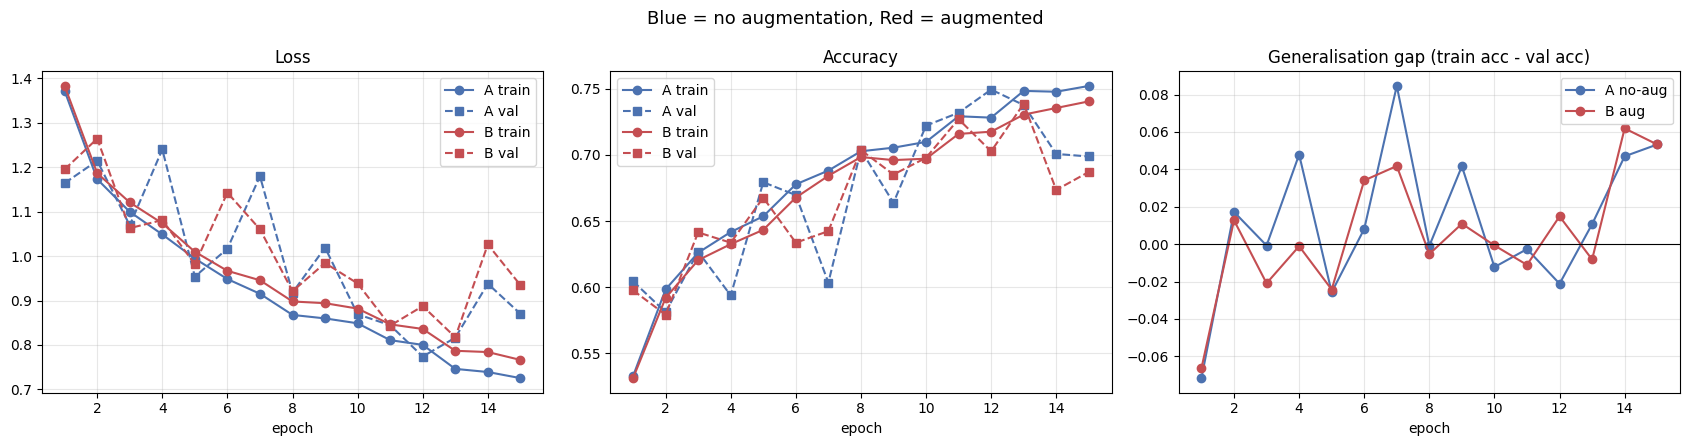

                best val acc   final gap  time (min)
A no-aug              74.9%        5.3%         6.6
B aug                 73.9%        5.3%         6.9


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, hist_A["train_loss"], "o-", c="#4C72B0", label="A train")
axes[0].plot(ep, hist_A["val_loss"], "s--", c="#4C72B0", label="A val")
axes[0].plot(ep, hist_B["train_loss"], "o-", c="#C44E52", label="B train")
axes[0].plot(ep, hist_B["val_loss"], "s--", c="#C44E52", label="B val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, hist_A["train_acc"], "o-", c="#4C72B0", label="A train")
axes[1].plot(ep, hist_A["val_acc"], "s--", c="#4C72B0", label="A val")
axes[1].plot(ep, hist_B["train_acc"], "o-", c="#C44E52", label="B train")
axes[1].plot(ep, hist_B["val_acc"], "s--", c="#C44E52", label="B val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

gap_A = [t - v for t, v in zip(hist_A["train_acc"], hist_A["val_acc"])]
gap_B = [t - v for t, v in zip(hist_B["train_acc"], hist_B["val_acc"])]
axes[2].plot(ep, gap_A, "o-", c="#4C72B0", label="A no-aug")
axes[2].plot(ep, gap_B, "o-", c="#C44E52", label="B aug")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_title("Generalisation gap (train acc - val acc)")
axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Blue = no augmentation, Red = augmented", fontsize=13)
plt.tight_layout(); plt.show()

print(f"{'':<14}{'best val acc':>14}{'final gap':>12}{'time (min)':>12}")
print(f"{'A no-aug':<14}{hist_A['best_val_acc']:>13.1%}{gap_A[-1]:>12.1%}{hist_A['total_time']/60:>12.1f}")
print(f"{'B aug':<14}{hist_B['best_val_acc']:>13.1%}{gap_B[-1]:>12.1%}{hist_B['total_time']/60:>12.1f}")

### Q1. What happened? *(write your answer below)*

Look specifically at the **third panel**, the generalisation gap. A large positive gap means the model performs far better on data it has memorised than on data it has not seen.

- Which run has the larger gap, and by how much?
- Did augmentation improve the *training* accuracy? Did it improve the *validation* accuracy? Explain why those two answers differ.
- Run A's training accuracy is probably very high. Why is that not good news?

> **Your answer to Q1:**
>
> *My Answer: Run A had a difference in how well it did but both Run A and Run B were pretty much the same at around 5.3 percent. Adding things to the data did not really make the results any better. Run A was better, at learning from the training data. It also did a little bit better on the validation data with 74.9 percent compared to Run B which had 73.9 percent. This shows that Run A and Run B can have training accuracy but Run A and Run B do not always do better on new data just because the training accuracy is high*

---

## Part 7 — Evaluate properly *(TODO)*

From here on, use the better of your two models. This is the **only** time you touch the test set.

In [18]:
best_model = model_B if hist_B["best_val_acc"] >= hist_A["best_val_acc"] else model_A
best_name = "B (augmented)" if best_model is model_B else "A (no augmentation)"
print(f"Selected on validation accuracy: Run {best_name}")
print("Note we chose using VALIDATION, not test. Choosing on test would invalidate it.")

Selected on validation accuracy: Run A (no augmentation)
Note we chose using VALIDATION, not test. Choosing on test would invalidate it.


### 7a. Collect predictions *(TODO)*

Run the test set through the model and build two flat lists: `y_true` and `y_pred`.

Three things to get right:
- `best_model.eval()` before you start
- wrap the loop in `torch.no_grad()`
- the model outputs 11 raw scores per image — convert to a class index with `.argmax(1)`

In [19]:
### TODO 7a ----------------------------------------------------------------
y_true, y_pred = [], []

# TODO: set eval mode, loop over test_loader under no_grad,
#       append true labels to y_true and predicted class indices to y_pred

# --------------------------------------------------------------------------
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = best_model(x)
        preds = outputs.argmax(1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [20]:
# --- CHECK 7a ---
assert len(y_true) == len(test_idx), f"got {len(y_true)} predictions, expected {len(test_idx)}"
assert len(y_pred) == len(y_true), "y_true and y_pred must be the same length"
assert y_pred.max() < NUM_CLASSES and y_pred.min() >= 0, \
    "y_pred should hold class indices 0-10, not raw scores - did you use argmax?"
acc = (y_true == y_pred).mean()
assert acc > 0.25, f"accuracy {acc:.1%} is near chance - something is wrong"
print(f"PASSED. {len(y_true)} test predictions collected.")
print(f"Test accuracy: {acc:.1%}")

PASSED. 1030 test predictions collected.
Test accuracy: 73.8%


### 7b. Confusion matrix *(TODO)*

Build the 11×11 matrix and plot it as a heatmap. Entry `(i, j)` = number of images whose true class is `i` and predicted class is `j`.

Use `sklearn.metrics.confusion_matrix`. Plot with `plt.imshow`, label **both** axes with class names, and annotate each cell with its count — an unlabelled confusion matrix is unreadable and therefore useless.

**Also produce a row-normalised version** (each row divided by its sum). Raw counts are dominated by the large classes; row-normalising shows you the per-class *error rate*, which is what you actually want to compare.

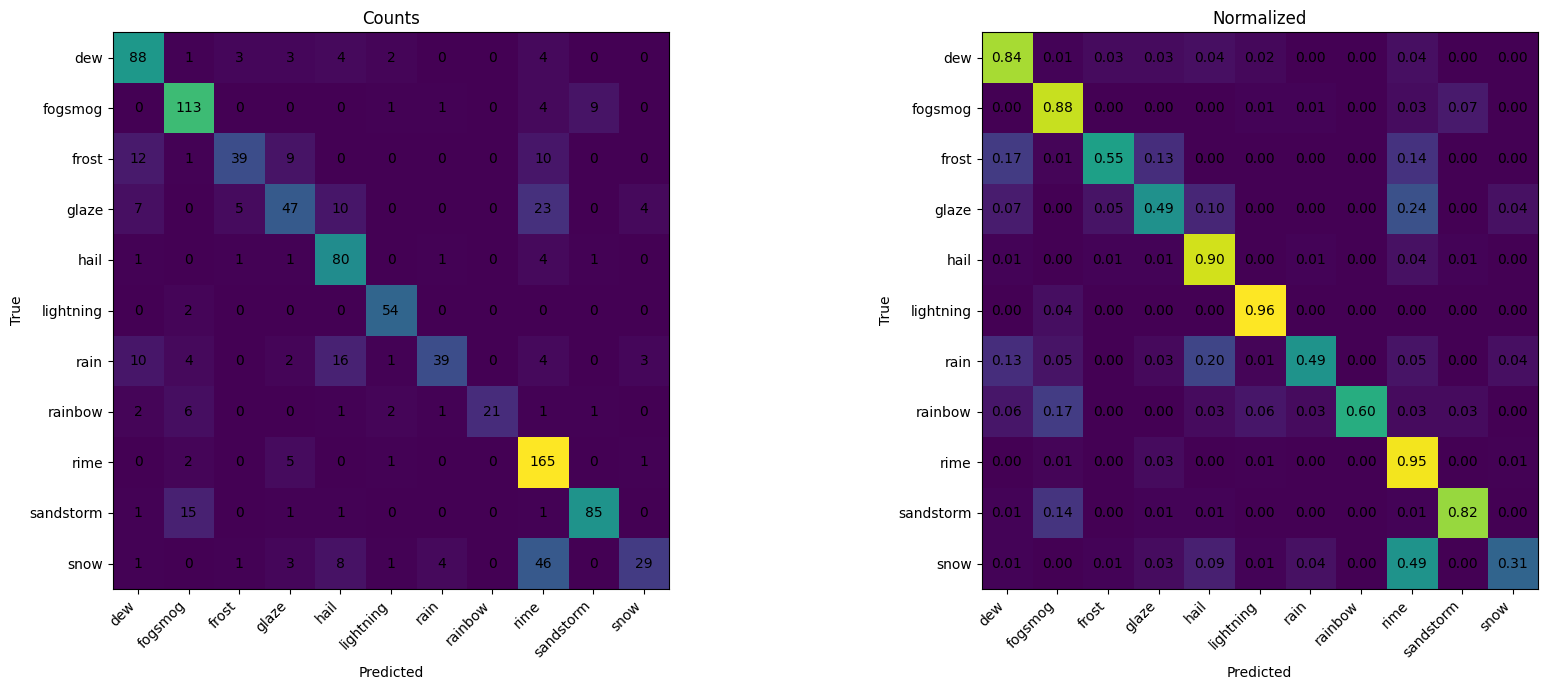

In [23]:
from sklearn.metrics import confusion_matrix

### TODO 7b ----------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)         # TODO: raw counts, shape (11, 11)
cm_norm =  cm / cm.sum(axis=1, keepdims=True)     # TODO: cm with each ROW divided by that row's sum

# TODO: plot both as side-by-side heatmaps with class names on both axes
#       and the numbers written into the cells

# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, title in zip(axes, [cm, cm_norm], ["Counts", "Normalized"]):
    ax.imshow(data)
    ax.set_title(title)
    ax.set_xticks(range(NUM_CLASSES), CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES), CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{data[i,j]:.2f}" if data is cm_norm else data[i,j],
                    ha="center", va="center")

plt.tight_layout()
plt.show()

In [24]:
# --- CHECK 7b ---
assert cm.shape == (NUM_CLASSES, NUM_CLASSES), f"cm shape {cm.shape}"
assert cm.sum() == len(y_true), "confusion matrix total should equal number of test images"
assert np.allclose(cm_norm.sum(axis=1), 1.0), \
    "each ROW of cm_norm must sum to 1.0 - check you divided by row sums, not column sums"
print("PASSED.")
print(f"Correct predictions on the diagonal: {np.trace(cm)} / {cm.sum()}")

PASSED.
Correct predictions on the diagonal: 760 / 1030


### 7c. Per-class metrics *(TODO)*

Produce a table with **precision, recall, F1 and support** for each of the 11 classes, plus macro and weighted averages.

`sklearn.metrics.classification_report` does this in one line — pass `target_names=CLASSES`, `digits=3`, and `zero_division=0`.

Then pull out `macro avg` F1 and `weighted avg` F1 as numbers, because you need them for the summary.

In [25]:
from sklearn.metrics import classification_report, f1_score

### TODO 7c ----------------------------------------------------------------
# TODO: print the classification report

macro_f1 = f1_score(y_true, y_pred, average="macro")      # TODO: f1_score(..., average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")   # TODO: f1_score(..., average="weighted")

# --------------------------------------------------------------------------

In [26]:
# --- CHECK 7c ---
assert 0 < macro_f1 < 1 and 0 < weighted_f1 < 1, "F1 scores should be between 0 and 1"
print(f"PASSED.")
print(f"Macro F1    : {macro_f1:.3f}   (all classes weighted equally)")
print(f"Weighted F1 : {weighted_f1:.3f}   (weighted by class size)")
print(f"Difference  : {weighted_f1 - macro_f1:+.3f}")
if weighted_f1 - macro_f1 > 0.05:
    print("\n-> Weighted is clearly higher than macro. Your model is doing")
    print("   noticeably worse on the SMALL classes. Find out which in Q3.")

PASSED.
Macro F1    : 0.721   (all classes weighted equally)
Weighted F1 : 0.723   (weighted by class size)
Difference  : +0.002


### 7d. Which mistakes are the most common?

Given to you — this is usually more actionable than staring at the matrix.

In [27]:
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], cm_norm[i, j], CLASSES[i], CLASSES[j]))
pairs.sort(reverse=True)

print(f"{'count':>6}{'% of true class':>17}  confusion")
print("-" * 55)
for cnt, frac, true_c, pred_c in pairs[:10]:
    print(f"{cnt:>6}{frac:>16.1%}  {true_c} -> predicted as {pred_c}")

 count  % of true class  confusion
-------------------------------------------------------
    46           49.5%  snow -> predicted as rime
    23           24.0%  glaze -> predicted as rime
    16           20.3%  rain -> predicted as hail
    15           14.4%  sandstorm -> predicted as fogsmog
    12           16.9%  frost -> predicted as dew
    10           14.1%  frost -> predicted as rime
    10           12.7%  rain -> predicted as dew
    10           10.4%  glaze -> predicted as hail
     9           12.7%  frost -> predicted as glaze
     9            7.0%  fogsmog -> predicted as sandstorm


---

## Part 8 — Written analysis

These are the deliverable. Answer them from **your own numbers**, not from general knowledge.

### Q2. Which classes does your model confuse, and why?

Look at your top confusion pairs above and at the off-diagonal blocks in the heatmap.

- Name the two or three most confused pairs.
46 image    49.5%    snow  -> predicted as rime 
23 image   24.0%    glaze -> predicted as rime
16 image   20.3%    rain  -> predicted as hail
- Open a few images from each of those classes (use the sampler cell below). Can *you* tell them apart reliably? I could tell some images apart, but others looked almost the same

- Are these mistakes *sensible* — confusions a careful human might also make — or arbitrary? What does that tell you about whether the model learned something real?
Yes, the mistakes make sense because the confused classes have similar features

Your most common mistake: snow predicted as rime


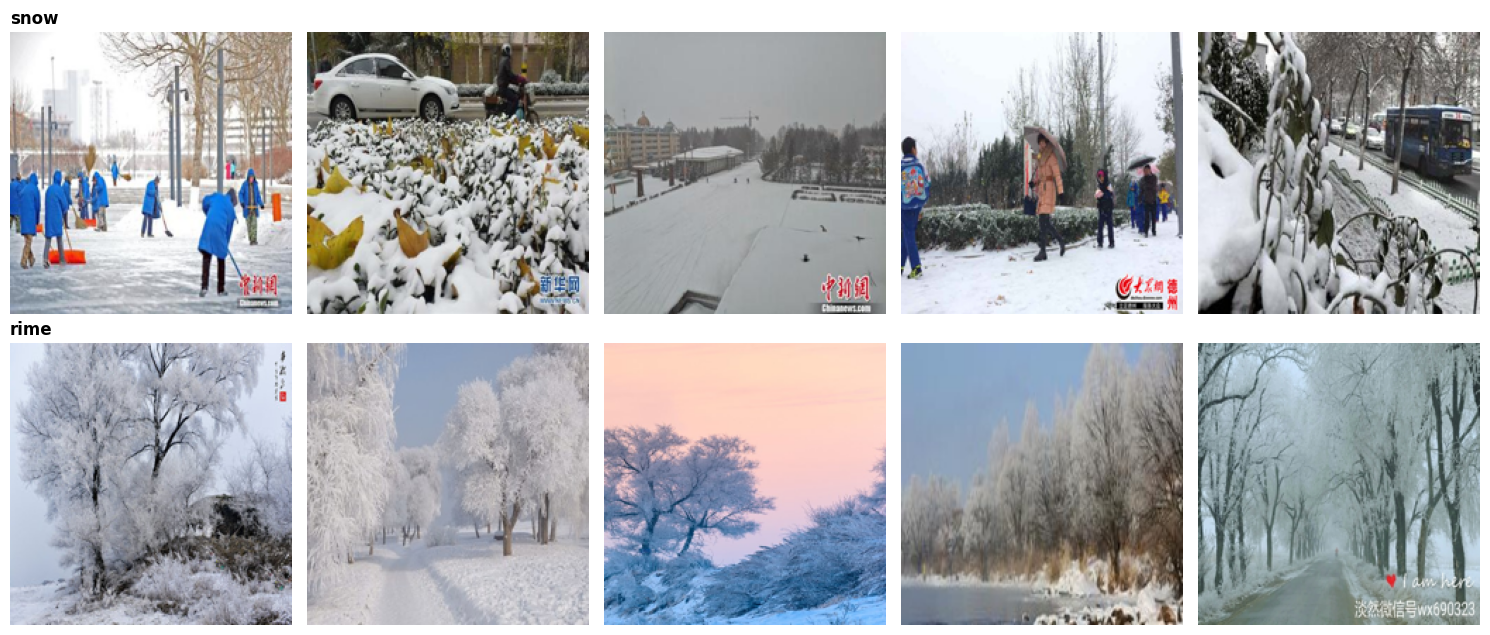

In [28]:
# Helper: view images from any two classes side by side
def compare_classes(a, b, n=5):
    for c in (a, b):
        if c not in CLASSES:
            raise ValueError(f"'{c}' is not a class. Available: {CLASSES}")
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6.5))
    for row, cname in enumerate([a, b]):
        ci = CLASSES.index(cname)
        paths = [p for p, t in full.samples if t == ci]
        for col, p in enumerate(random.sample(paths, min(n, len(paths)))):
            axes[row, col].imshow(Image.open(p).convert("RGB").resize((200, 200)))
            axes[row, col].axis("off")
        axes[row, 0].set_title(cname, loc="left", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()


# Defaults to YOUR top confusion pair. Change the two names to inspect any other pair.
top_true, top_pred = pairs[0][2], pairs[0][3]
print(f"Your most common mistake: {top_true} predicted as {top_pred}")
compare_classes(top_true, top_pred)

> **Your answer to Q2:**
>
> I could tell some images apart, but others looked almost the same

### Q3. Does poor recall track class size?

Build a small table of every class with its **recall** and its **number of training images**, sorted by recall.

- Which class has the worst recall?
- Is it also among the smallest classes?
- Is the relationship consistent across all 11 classes, or are there exceptions — a small class the model handles well, or a large class it handles badly? What could explain an exception?

In [29]:
### TODO Q3 ----------------------------------------------------------------
# TODO: print each class with its recall and its support (test-set count),
#       sorted from worst recall to best.
# Hint: recall for class i is cm[i, i] / cm[i].sum()

# --------------------------------------------------------------------------
recalls = []

for i in range(NUM_CLASSES):
    recall = cm[i, i] / cm[i].sum()
    support = cm[i].sum()
    recalls.append((CLASSES[i], recall, support))

recalls.sort(key=lambda x: x[1])

for class_name, recall, support in recalls:
    print(class_name, recall, support)

snow 0.3118279569892473 93
glaze 0.4895833333333333 96
rain 0.4936708860759494 79
frost 0.5492957746478874 71
rainbow 0.6 35
sandstorm 0.8173076923076923 104
dew 0.8380952380952381 105
fogsmog 0.8828125 128
hail 0.898876404494382 89
rime 0.9482758620689655 174
lightning 0.9642857142857143 56


> **Your answer to Q3:**
>
> *Snow is really bad at being recognized it only gets it right 31 percent of the time. Then there is glaze and rain they are not great either they get it right 49 percent of the time.. It does not seem like the problem is just that there are not enough pictures of something. For example lightning doesn't have a lot of pictures but the model is really good at recognizing Snow and lightning it gets it right 96 percent of the time. This means the model is better at recognizing some things, like lightning than it is at recognizing Snow.. Sometimes the model gets confused between things that look similar, like Snow and rime because they look a lot alike*

### Q4. Precision vs recall — a decision

Pick the class where precision and recall differ most in your report.

- State both numbers and explain, in plain language, what each one means *for that specific class*. ("When the model says X, it is right P% of the time" / "Of all the real X images, it found R% of them.")
- Now suppose this model drives a weather warning system. For a **hail** warning, which is more costly: low precision (false alarms) or low recall (missed hailstorms)? Justify it.
- Given that answer, would overall accuracy have been a sufficient metric to report? Why not?

> **Your answer to Q4:**
>
> *When it comes to a hail warning system I think it is really bad if the system misses a hail storm. This is what happens when the system has recall. If the system does not tell us about a hail storm that is actually coming that can be very dangerous. On the hand if the system tells us about a hail storm that is not coming that is just annoying.. Missing a real hail storm is much worse because it can hurt people. This is why we need to look at more than how often the system is right. We need to know how the hail warning system detects hail storms and how well it detects times when there is no hail storm. The hail warning system needs to be good, at finding the hail storms*

---

## Part 9 — Save your baseline

**Do not skip this.** Tomorrow's lab compares transfer learning against these exact numbers.

In [30]:
OUT = Path("/kaggle/working")

torch.save({
    "model_state": best_model.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "test_acc": float(acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "n_params": sum(p.numel() for p in best_model.parameters()),
    "train_time_min": (hist_B if best_model is model_B else hist_A)["total_time"] / 60,
    "run": best_name,
}, OUT / "task1_baseline.pt")

print("=" * 58)
print("  DAY 1 BASELINE - WRITE THESE DOWN")
print("=" * 58)
print(f"  Model            : CNN from scratch ({best_name})")
print(f"  Trainable params : {sum(p.numel() for p in best_model.parameters()):,}")
print(f"  Test accuracy    : {acc:.1%}")
print(f"  Macro F1         : {macro_f1:.3f}")
print(f"  Weighted F1      : {weighted_f1:.3f}")
print("=" * 58)
print("\nSaved to /kaggle/working/task1_baseline.pt")
print("Download it, or note the numbers. You need them tomorrow.")

  DAY 1 BASELINE - WRITE THESE DOWN
  Model            : CNN from scratch (A (no augmentation))
  Trainable params : 392,203
  Test accuracy    : 73.8%
  Macro F1         : 0.721
  Weighted F1      : 0.723

Saved to /kaggle/working/task1_baseline.pt
Download it, or note the numbers. You need them tomorrow.


---

## Submission checklist

- [ ] All CHECK cells pass
- [ ] Both runs trained for 15 epochs
- [ ] Comparison plot showing loss, accuracy, and generalisation gap
- [ ] Confusion matrix, both raw and row-normalised, with labelled axes
- [ ] Per-class precision / recall / F1 table
- [ ] Q1–Q4 answered from your own numbers
- [ ] Baseline test accuracy and macro F1 recorded

### One last thing

Your accuracy is probably somewhere around 60–70%. That may feel disappointing. It should not — it is a completely reasonable result for a 300,000-parameter network trained for six minutes on 4,800 images.

Tomorrow you will pass 90% in about twelve lines of code, without designing a single layer. **Come back with your number.**